#  Sales Prediction using Linear Regression

This project predicts sales based on advertising budget using machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('advertising.csv')
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


,0
TV,0
Radio,0
Newspaper,0
Sales,0


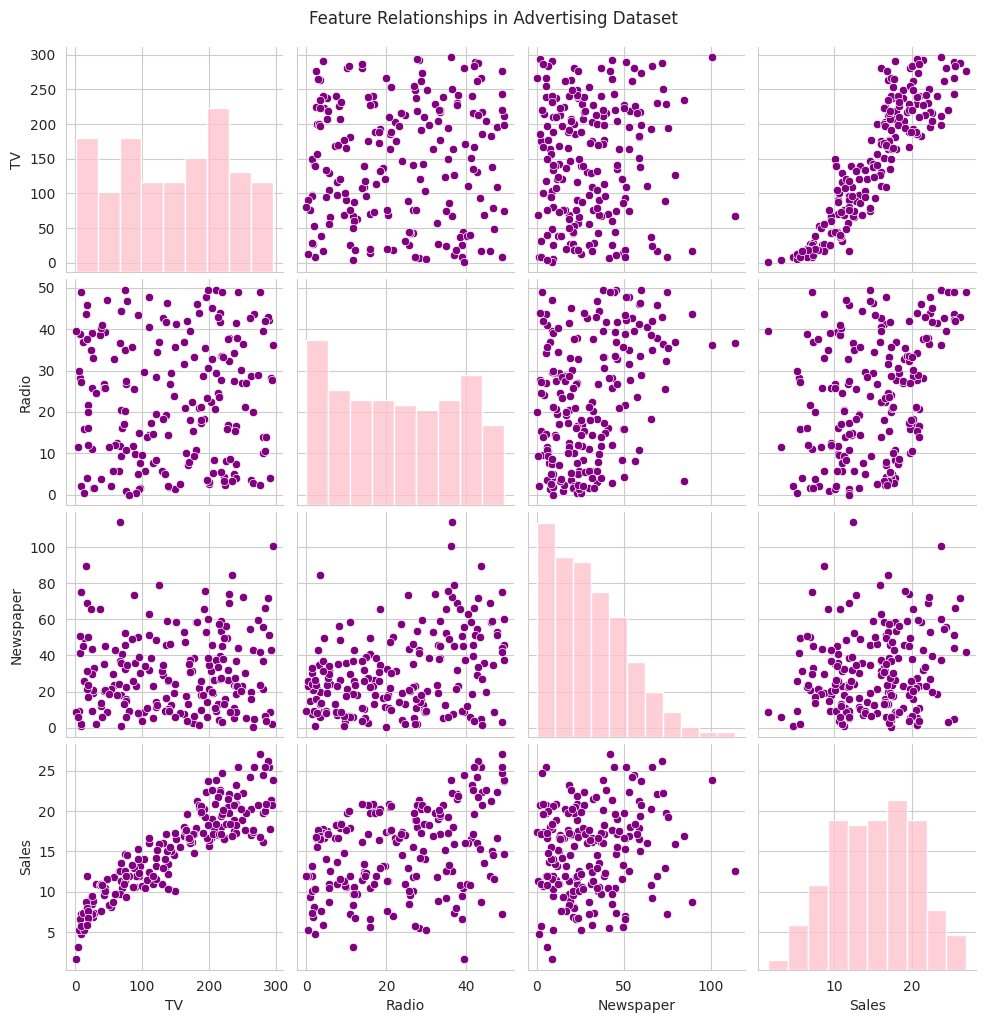

In [12]:
g = sns.pairplot(
    df,
    plot_kws={"color": "purple"},
    diag_kws={"color": "pink"}
)

g.fig.suptitle("Feature Relationships in Advertising Dataset", y=1.02)

plt.show()

<br>

### Visualization Insight
- TV advertising shows strong correlation with Sales
- Radio has moderate impact
- Newspaper has weak impact

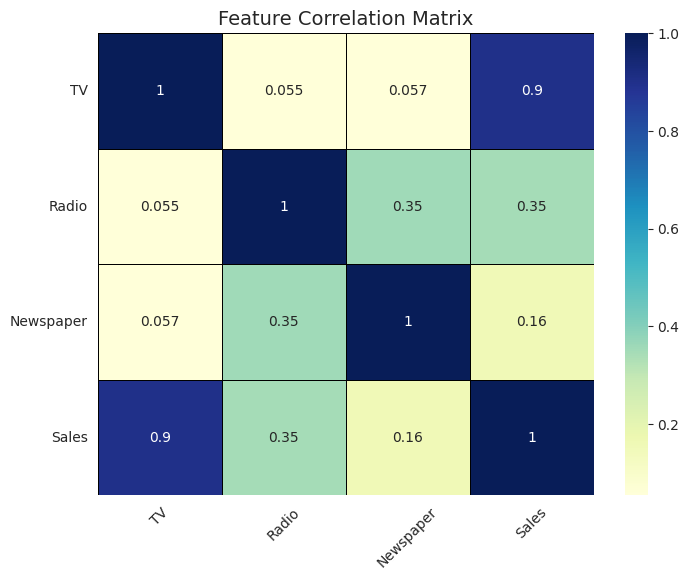

In [19]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="YlGnBu",
    linewidths=0.5,
    linecolor='black'
)

plt.title("Feature Correlation Matrix", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

<br>

### Key Insights

-  TV advertising has a strong impact on sales (~0.9 correlation)
-  Radio has moderate influence
-  Newspaper has minimal effect

In [13]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Coefficients: [0.05450927 0.10094536 0.00433665]
Intercept: 4.714126402214127


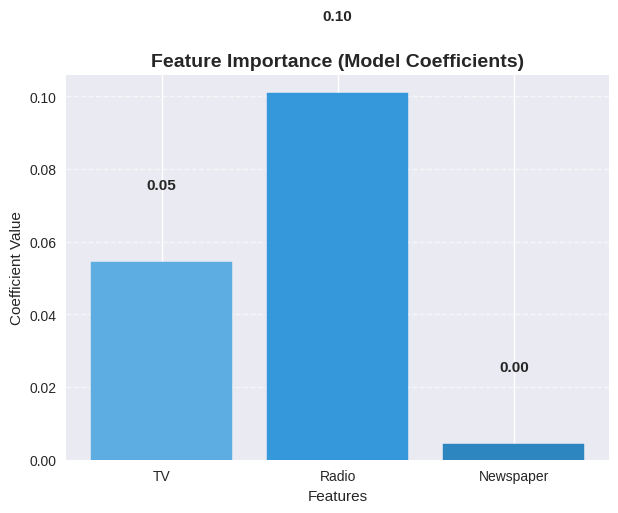

In [30]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)
features = ['TV', 'Radio', 'Newspaper']
coefficients = model.coef_

plt.figure(figsize=(7,5))

bars = plt.bar(features, coefficients)

colors = ['#5DADE2', '#3498DB', '#2E86C1']
for bar, color in zip(bars, colors):
    bar.set_color(color)

for i, v in enumerate(coefficients):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=11, fontweight='bold')

plt.title("Feature Importance (Model Coefficients)", fontsize=14, fontweight='bold')
plt.xlabel("Features")
plt.ylabel("Coefficient Value")

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

<br>

###  Model Interpretation

- Coefficients show how each advertising channel affects sales  
- Higher coefficient means stronger impact on sales  

In [16]:
y_pred = model.predict(X_test)

MAE: 1.2748262109549338
MSE: 2.9077569102710896
R2 Score: 0.9059011844150826


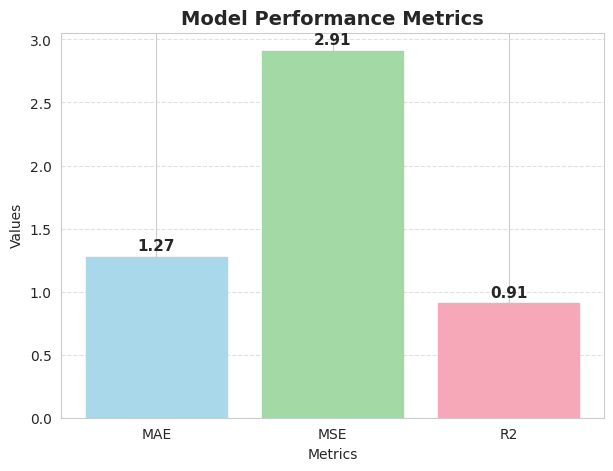

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)
metrics = ['MAE', 'MSE', 'R2']
values = [mae, mse, r2]

plt.figure(figsize=(7,5))

bars = plt.bar(metrics, values)

colors = ['#A8D8EA', '#A3D9A5', '#F7A8B8']
for bar, color in zip(bars, colors):
    bar.set_color(color)

for i, v in enumerate(values):
    plt.text(i, v + 0.05, f"{v:.2f}", ha='center', fontsize=11, fontweight='bold')

plt.title("Model Performance Metrics", fontsize=14, fontweight='bold')
plt.xlabel("Metrics")
plt.ylabel("Values")

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

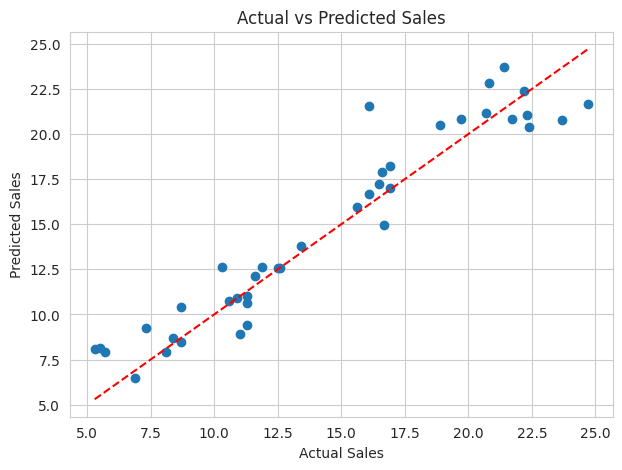

In [20]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

<br>

### 📈 Model Insight

The points are close to the diagonal line, showing that predicted values are very close to actual values, indicating good model performance.